In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict

In [2]:
GRID_SIZE = 4
ACTIONS = ['U', 'D', 'L', 'R']
ACTION_MAP = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1)
}
GAMMA = 0.9

def step(state, action):
    if state == (3, 3):
        return state, 0, True

    dx, dy = ACTION_MAP[action]
    nx, ny = state[0] + dx, state[1] + dy
    nx, ny = max(0, min(nx, 3)), max(0, min(ny, 3))
    return (nx, ny), -1, (nx, ny) == (3, 3)

## 1. Dynamic Programming (Value Iteration)

Assumptions
- Full knowledge of the MDP: transition probabilities and rewards
- Finite states and actions

In [3]:
V = np.zeros((GRID_SIZE, GRID_SIZE))
policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
history = []

theta = 1e-4
while True:
    delta = 0
    new_V = V.copy()
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            if (i, j) == (3, 3):
                continue
            values = []
            for a in ACTIONS:
                (ni, nj), r, _ = step((i, j), a)
                values.append(r + GAMMA * V[ni, nj])
            new_V[i, j] = max(values)
            delta = max(delta, abs(new_V[i, j] - V[i, j]))
    V = new_V
    history.append(V.copy())
    if delta < theta:
        break

# Extract policy
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if (i, j) == (3, 3):
            continue
        policy[i, j] = np.argmax([
            step((i, j), a)[1] + GAMMA * V[step((i, j), a)[0]]
            for a in ACTIONS
        ])

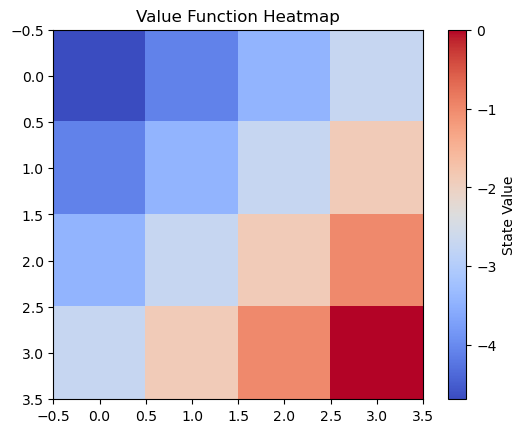

In [4]:
plt.imshow(V, cmap='coolwarm')
plt.colorbar(label="State Value")
plt.title("Value Function Heatmap")
plt.show()

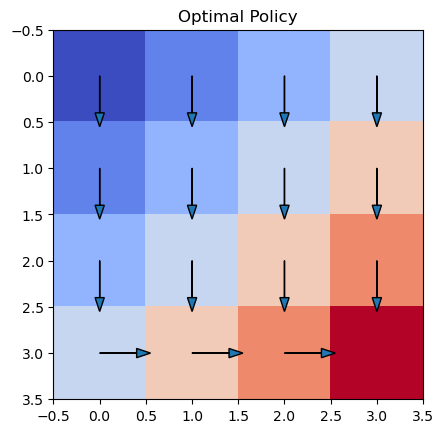

In [5]:
arrow_map = {'U': (0, -0.4), 'D': (0, 0.4), 'L': (-0.4, 0), 'R': (0.4, 0)}

plt.imshow(V, cmap='coolwarm')
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if (i, j) != (3, 3):
            dx, dy = arrow_map[ACTIONS[policy[i, j]]]
            plt.arrow(j, i, dx, dy, head_width=0.1)
plt.title("Optimal Policy")
plt.show()

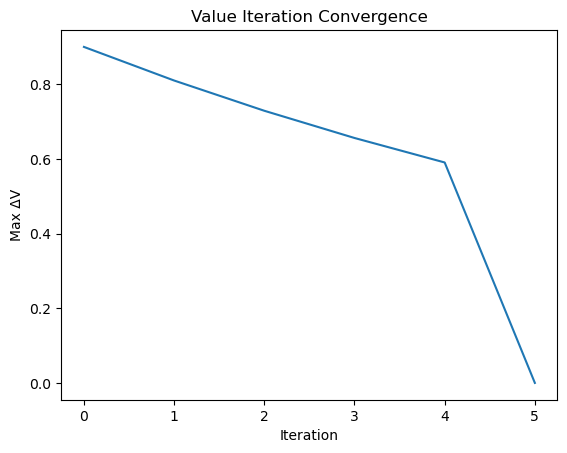

In [6]:
deltas = [np.max(np.abs(history[i] - history[i-1])) for i in range(1, len(history))]

plt.plot(deltas)
plt.xlabel("Iteration")
plt.ylabel("Max ΔV")
plt.title("Value Iteration Convergence")
plt.show()

## 2. Monte Carlo Methods (First-Visit MC Control)

Assumptions
- No model of the environment
- Learn from complete episodes
- Episodic task

In [7]:
Q = defaultdict(float)
returns = defaultdict(list)
episode_returns = []

EPSILON = 0.1
EPISODES = 5000
MAX_STEPS = 100

def epsilon_greedy(state):
    if random.random() < EPSILON:
        return random.choice(ACTIONS)
    return max(ACTIONS, key=lambda a: Q[(state, a)])

for _ in range(EPISODES):
    state = (0, 0)
    episode = []
    G = 0

    for _ in range(MAX_STEPS):
        action = epsilon_greedy(state)
        next_state, reward, done = step(state, action)
        episode.append((state, action, reward))
        G += reward
        state = next_state
        if done:
            break

    episode_returns.append(G)

    visited = set()
    G = 0
    for s, a, r in reversed(episode):
        G = GAMMA * G + r
        if (s, a) not in visited:
            returns[(s, a)].append(G)
            Q[(s, a)] = np.mean(returns[(s, a)])
            visited.add((s, a))

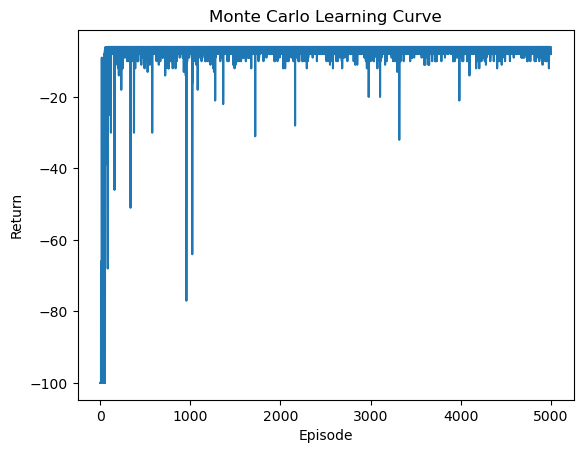

In [8]:
plt.plot(episode_returns)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("Monte Carlo Learning Curve")
plt.show()

In [9]:
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        print(f"State {(i,j)}:", {a: round(Q[((i,j),a)],2) for a in ACTIONS})

State (0, 0): {'U': np.float64(-5.98), 'D': np.float64(-4.97), 'L': np.float64(-6.08), 'R': np.float64(-5.61)}
State (0, 1): {'U': np.float64(-6.68), 'D': np.float64(-4.47), 'L': np.float64(-7.91), 'R': np.float64(-8.57)}
State (0, 2): {'U': np.float64(-5.79), 'D': np.float64(-6.79), 'L': np.float64(-6.84), 'R': np.float64(-6.32)}
State (0, 3): {'U': np.float64(-5.37), 'D': np.float64(-3.53), 'L': np.float64(-8.59), 'R': np.float64(-7.42)}
State (1, 0): {'U': np.float64(-5.58), 'D': np.float64(-4.56), 'L': np.float64(-5.05), 'R': np.float64(-4.36)}
State (1, 1): {'U': np.float64(-5.24), 'D': np.float64(-3.63), 'L': np.float64(-5.26), 'R': np.float64(-4.08)}
State (1, 2): {'U': np.float64(-8.48), 'D': np.float64(-2.9), 'L': np.float64(-4.45), 'R': np.float64(-3.84)}
State (1, 3): {'U': np.float64(-4.31), 'D': np.float64(-2.58), 'L': np.float64(-7.2), 'R': np.float64(-3.94)}
State (2, 0): {'U': np.float64(-6.25), 'D': np.float64(-3.66), 'L': np.float64(-5.23), 'R': np.float64(-4.28)}
Sta

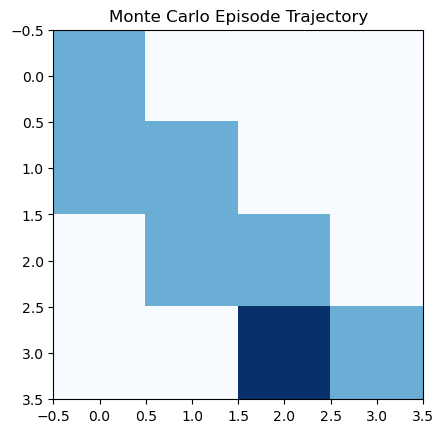

In [10]:
path = [(0,0)]
state = (0,0)
for _ in range(20):
    action = epsilon_greedy(state)
    state, _, done = step(state, action)
    path.append(state)
    if done:
        break

grid = np.zeros((GRID_SIZE, GRID_SIZE))
for i,j in path:
    grid[i,j] += 1

plt.imshow(grid, cmap='Blues')
plt.title("Monte Carlo Episode Trajectory")
plt.show()


## 3. Temporal-Difference Learning (Q-Learning)

Assumptions
- No model required
- Learns online, step-by-step
- Off-policy

In [11]:
Q = defaultdict(float)
alpha = 0.1
td_errors = []
policy_changes = []

for episode in range(3000):
    state = (0, 0)
    changes = 0

    for _ in range(100):
        if random.random() < EPSILON:
            action = random.choice(ACTIONS)
        else:
            action = max(ACTIONS, key=lambda a: Q[(state, a)])

        next_state, reward, done = step(state, action)
        best_next = max(Q[(next_state, a)] for a in ACTIONS)
        td_error = reward + GAMMA * best_next - Q[(state, action)]
        Q[(state, action)] += alpha * td_error
        td_errors.append(abs(td_error))

        if done:
            break
        state = next_state

    policy_changes.append(changes)

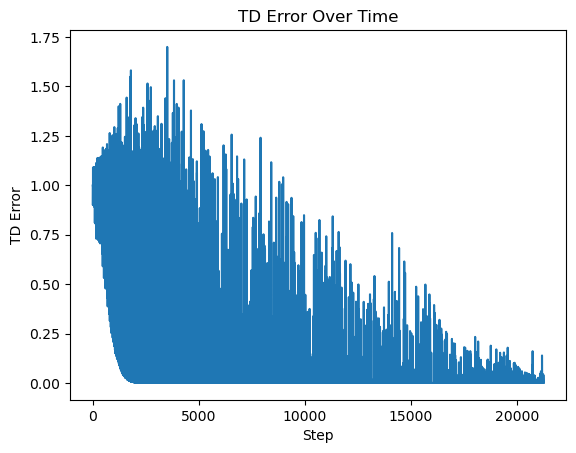

In [12]:
plt.plot(td_errors)
plt.xlabel("Step")
plt.ylabel("TD Error")
plt.title("TD Error Over Time")
plt.show()

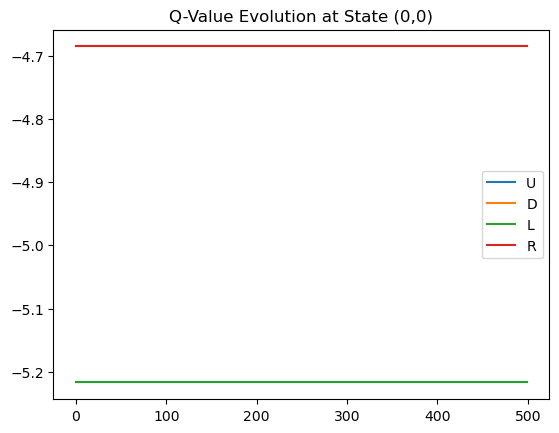

In [13]:
state = (0, 0)
q_values = {a: [] for a in ACTIONS}

for _ in range(500):
    for a in ACTIONS:
        q_values[a].append(Q[(state, a)])

for a in ACTIONS:
    plt.plot(q_values[a], label=a)

plt.legend()
plt.title("Q-Value Evolution at State (0,0)")
plt.show()

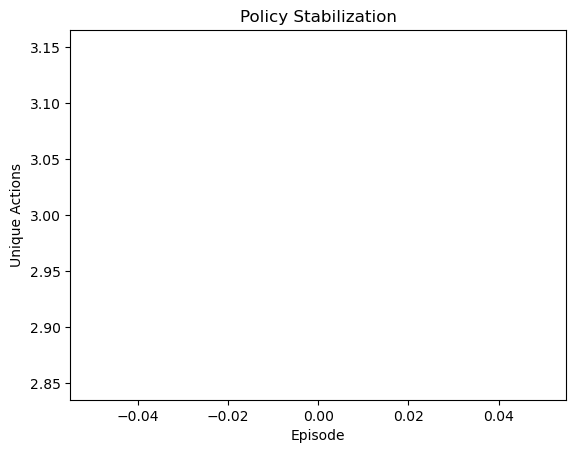

In [14]:
policy = {}
policy_history = []

for (s, a), v in Q.items():
    policy[s] = max(ACTIONS, key=lambda x: Q[(s, x)])

policy_history.append(len(set(policy.values())))

plt.plot(policy_history)
plt.title("Policy Stabilization")
plt.xlabel("Episode")
plt.ylabel("Unique Actions")
plt.show()